In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.d_k = d_k

    def forward (self, Q, K, V, mask=None):
        #input [batch, number_of_heads, sequence_length, d_model] for all Q,K,V
        d_k = Q.size(-1)                                                          #fetching the dimension since d_k = d_model
        K_t = K.transpose(-1,-2)                                                  #transposing last two dimensions of the keys matrix for multiplication
        scaled_value = torch.matmul(Q,K_t)/math.sqrt(d_k)                    #scaling the dot product
        if mask is not None:
            if mask.dtype != torch.bool:
                mask = mask.bool()
            scaled_value=  scaled_value.masked_fill(~mask,-1e9)         #masking
        final_value = torch.softmax(scaled_value,-1)@V                  #softmax over last dimension because we are normalizing it
        return final_value

class MultiHeadAttention(nn.Module):

    def __init__(self,d_model,num_heads):
        super().__init__()
        self.n = num_heads                              #Initialize number of heads and model dimension
        self.D = d_model
        self.W_q = nn.Linear(d_model,d_model)               #initialize weights, vaswani et al paper states that the queries, keys and values are to be linearly projected h times with different learned linear projections
        self.W_k = nn.Linear(d_model,d_model)               #MultiHead(Q,K,V) = Concat(h_1,h_2,....h_n)*W_o W_o is the output projection
        self.W_v = nn.Linear(d_model,d_model)               #head_i = Attention(QW_qi,KW_ki,V_Wvi)
        self.W_o = nn.Linear(d_model,d_model)
        self.attention = ScaledDotProductAttention(num_heads)


    def split_heads(self,X):
        #Assuming the input format for Q,K,V to be [batch, sequence_len, d_model]
        B,S,D = X.shape
        n = self.n
        X = X.reshape(B,S,n,D//n)
        return X

    def merge_heads(self,X):
        # Merging the heads after attention
        B, n , S, d = X.shape
        n = self.n
        X = X.transpose(-2,-3)
        X = X.reshape(B,S,d*n) # you could use .view instead by making the tensor contiguous using .contiguous() method
        return X

    def forward  (self,Q,K,V,mask):

        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)
        Q = self.split_heads(Q).transpose(-2,-3)             #Using self.split_heads from the same parent class to swap number of heads and sequence length
        K = self.split_heads(K).transpose(-2,-3)
        V = self.split_heads(V).transpose(-2,-3)

        attended_values = self.attention(Q,K,V,mask)

        attended_values = self.merge_heads(attended_values)  #Using self.merge_heads to merge all the heads i.e concatenate the values before running through output projection
        output_values = self.W_o(attended_values)
        return output_values

class EncoderBlock(nn.Module):

    def __init__(self,d_model,num_heads,d_ff,dropout):
        super().__init__()
        self.d_model=d_model
        self.d_ff = d_ff
        self.num_heads=num_heads
        self.multiheadattention = MultiHeadAttention(d_model,num_heads)
        self.linear_one = nn.Linear(d_model,d_ff)                  #Transformer FFN structure linear(d_model to d_ff)-->activation -->linear(d_ff to d_model)
        self.linear_two = nn.Linear(d_ff,d_model)
        self.dropout= nn.Dropout(p=dropout)
        self.layernorm = nn.LayerNorm(d_model)                                 #d_ff is typically 4 times d_model
        self.layernorm2 = nn.LayerNorm(d_model)

    def forward(self,x,mask=None):
        attention_output = self.multiheadattention(x,x,x,mask)                   #Attention block
        output_with_dropout = self.dropout(attention_output)
        layer_norm_output = self.layernorm(x + output_with_dropout)                 #modern methods use pre-LN i.e before attention happens the residual goes through layernorm i.e x--> layernorm -->attention

        feed_forward_output = self.linear_two(F.relu(self.linear_one(layer_norm_output)))               #FFN block here pre-LN would be x plus output with droput of sublayer
        ff_dropout = self.dropout(feed_forward_output)                                      #You can also write nn.functional.relu instead of F.relu but it is verbose
        layer_norm2_output = self.layernorm2(layer_norm_output + ff_dropout)                #mathematically a single layer norm works but residuals get mixed up

        return layer_norm2_output

class DecoderBlock(nn.Module):

    def __init__(self,d_model,num_heads,d_ff,dropout):
        super().__init__()
        self.d_ff = d_ff
        self.num_heads = num_heads
        self.multiheadattention = MultiHeadAttention(d_model, num_heads)
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.linear_one = nn.Linear(d_model, d_ff)
        self.linear_two = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(p=dropout)
        self.layernorm = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.layernorm3 = nn.LayerNorm(d_model)

    def sublayer_1(self,x,mask=None):
        # assuming the Q,K,V input to be [batch_size, seq_len, d_model]
        masked_self_attention = self.multiheadattention(x,x,x,mask)
        output_with_dropout = self.dropout(masked_self_attention)
        layer_norm_output = self.layernorm(x + output_with_dropout)

        return layer_norm_output #We feed this as query to the next sublayer along with encoder output as key

    def sublayer_2(self,sublayer_1_output,enc_output,src_mask):
        cross_attention=self.cross_attention(sublayer_1_output,enc_output,enc_output,src_mask)
        output_with_dropout = self.dropout(cross_attention)
        layer_norm2_output = self.layernorm2(sublayer_1_output + output_with_dropout)

        feed_forward_output = self.linear_two(F.relu(self.linear_one(layer_norm2_output)))
        ff_dropout = self.dropout(feed_forward_output)                                      #You can also write nn.functional.relu instead of F.relu but it is verbose
        layer_norm3_output = self.layernorm3(layer_norm2_output + ff_dropout)

        return layer_norm3_output

    def forward(self, x, enc_output, src_mask, tgt_mask):

        sublayer_1_output = self.sublayer_1(x,tgt_mask)
        sublayer_2_output = self.sublayer_2(sublayer_1_output,enc_output,src_mask)

        return sublayer_2_output

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout, max_len= 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        dimensional_matrix = torch.zeros(max_len,d_model, dtype = torch.float32)                #shape [max_len,d_model] interpretation row = token position in sequence and col = embedding dimenstion. it's like position n -> vector of size d_model
        positions = torch.arange(max_len, dtype = torch.float32).unsqueeze(1)               #Shape would be [max_len,1]
        i = torch.arange(0, d_model, 2, dtype = torch.float32)
        denominator_term = torch.exp(-(i/d_model) * math.log(10000)).unsqueeze(0)                #shape would be [1, d_model]. Note: We are using log here for numerical stability. this operation basically builds a 2D grid and every cell has unique frequency
        angles = positions * denominator_term               #this becomes [max_len, d_model] --> Angle = position * frequency

        dimensional_matrix[:, 0::2] = torch.sin(angles)                #projecting the values to dimensional matrix after encoding
        dimensional_matrix[:, 1::2] = torch.cos(angles)

        positional_encoding_matrix = dimensional_matrix.unsqueeze(0)              #adding a batch dimension to make it [1, max_len, d_model], transformers expect input shape like [batch_size, sequence_length, embedding_dim]

        self.register_buffer('pe', positional_encoding_matrix)              #register_buffer tells pyTorch to save this dimensional matrix with the model state and not update it with gradients when an optimizer is involved

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        x = self.dropout(x)
        return x

class Transformer(nn.Module):

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, N, num_heads, d_ff, dropout, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding_layer1 = nn.Embedding(src_vocab_size, d_model)
        self.embedding_layer2 = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model,dropout,max_len)
        self.encoder_stack = nn.ModuleList([EncoderBlock(d_model,num_heads,d_ff,dropout) for _ in range(N)]) ## we can't run a single encoder block in for loop N times i.e 6 times, this results in using same block 6 times and also weights are shared across layers
        self.decoder_stack = nn.ModuleList([DecoderBlock(d_model,num_heads,d_ff,dropout) for _ in range(N)])
        self.output_layer = nn.Linear(d_model,tgt_vocab_size)

    def forward(self,src,tgt,src_mask,tgt_mask):
        embeddings_1 = self.embedding_layer1(src)*math.sqrt(self.d_model)
        hidden_states_1 = self.positional_encoding(embeddings_1)
        for sheet in self.encoder_stack:
            hidden_states_1 = sheet(hidden_states_1,src_mask)  #adding mask here is necessary, in a real batch if we have to pad tokens to fir them into a tensor and we don't pass the mask, the efficiency goes down as self attention mechanism will waste resources work by calculating attention score to these padding tokens
        encoder_output = hidden_states_1
        embeddings_2 = self.embedding_layer2(tgt)*math.sqrt(self.d_model)
        hidden_states_2 = self.positional_encoding(embeddings_2)
        for sheet in self.decoder_stack:
            hidden_states_2 = sheet(hidden_states_2,encoder_output,src_mask,tgt_mask)
        decoder_output = hidden_states_2
        final_output = self.output_layer(decoder_output)

        return final_output


In [ ]:
#TRAINING LOOP 1 WITH 10000 SAMPLES

"""
Training pipeline for the Vaswani Transformer on a copy task.
Target is identical to source (random integer sequences).
"""

# --- Hyperparameters ---
VOCAB_SIZE = 100
PAD_ID = 0  # Also used as BOS for shifted decoder input
SEQ_LEN = 20
BATCH_SIZE = 32
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 512
DROPOUT = 0.1
LR = 1e-4
EPOCHS = 100


class CopyDataset(Dataset):
    """Dummy seq2seq dataset: target = source (copy task). Random integer sequences."""

    def __init__(self, num_samples, seq_len, vocab_size, pad_id=0, seed=None):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        if seed is not None:
            torch.manual_seed(seed)
        # Random ints 1..vocab_size-1 to avoid colliding with pad_id
        self.data = torch.randint(1, vocab_size, (num_samples, seq_len))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        src = self.data[idx].clone()
        # Decoder input: shifted right with PAD_ID at start
        tgt_input = torch.empty_like(src)
        tgt_input[0] = self.pad_id
        tgt_input[1:] = src[:-1]
        return src, tgt_input  # labels, decoder input


def create_masks(batch_size, seq_len, device):
    """Create src_mask (all ones, no padding) and tgt_mask (causal)."""
    src_mask = torch.ones(batch_size, 1, 1, seq_len, device=device)
    tgt_mask = torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device))
    return src_mask, tgt_mask


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset & DataLoader
    train_dataset = CopyDataset(
        num_samples=10_000, seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, pad_id=PAD_ID, seed=42
    )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )

    # Model
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,
        tgt_vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        N=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        dropout=DROPOUT,
        max_len=SEQ_LEN,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []  # Initialize list to store losses

    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0.0
        num_batches = 0
        for src, tgt_input in train_loader:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            src_mask, tgt_mask = create_masks(src.size(0), src.size(1), device)

            optimizer.zero_grad()
            logits = model(src, tgt_input, src_mask, tgt_mask)  # [B, T, vocab_size]

            # CrossEntropyLoss: predict src at each position
            logits_flat = logits.view(-1, VOCAB_SIZE)
            labels_flat = src.contiguous().view(-1)

            loss = criterion(logits_flat, labels_flat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss) # Append average loss for the epoch
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

    print("Training complete.")

    global global_train_losses_1 # Make it accessible outside main
    global_train_losses_1 = train_losses


if __name__ == "__main__":
    main()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(global_train_losses_1)
plt.title('Training Loss Curve (Run 1: LR = 1e-4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
#LOOP 2
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset & DataLoader
    train_dataset = CopyDataset(
        num_samples=32, seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, pad_id=PAD_ID, seed=42
    )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )

    # Model
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,
        tgt_vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        N=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        dropout=DROPOUT,
        max_len=SEQ_LEN,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses = []  # Initialize list to store losses

    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0.0
        num_batches = 0
        for src, tgt_input in train_loader:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            src_mask, tgt_mask = create_masks(src.size(0), src.size(1), device)

            optimizer.zero_grad()
            logits = model(src, tgt_input, src_mask, tgt_mask)  # [B, T, vocab_size]

            # CrossEntropyLoss: predict src at each position
            logits_flat = logits.view(-1, VOCAB_SIZE)
            labels_flat = src.contiguous().view(-1)

            loss = criterion(logits_flat, labels_flat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)  # Append average loss for the epoch
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

    print("Training complete.")

    global global_train_losses_2 # Make it accessible outside main
    global_train_losses_2 = train_losses


if __name__ == "__main__":
    main()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(global_train_losses_2)
plt.title('Training Loss Curve (Run 2: LR = 1e-3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Task
Modify cell `PsADs86z31OI` to split the dataset into 80% training and 20% validation sets, and implement a validation loop at the end of each epoch to calculate and print the validation loss using `model.eval()`, `model.train()`, and `torch.no_grad()`, storing the validation losses in `global_val_losses_1`. Additionally, modify cell `aCYjgftr61Eg` to adjust its dataset to 10,000 samples and then split it into 80% training and 20% validation sets, implementing a similar validation loop at the end of each epoch to calculate and print validation loss, storing these losses in `global_val_losses_2`. Summarize the implementation of train/validation splits, validation loss calculations, and the use of `model.eval()`, `model.train()`, and `torch.no_grad()` in both training loops.

## Modify Training Loop 1 for Validation

### Subtask:
Modify cell `PsADs86z31OI` to split the dataset into 80% training and 20% validation sets, and implement a validation loop at the end of each epoch to calculate and print the validation loss using `model.eval()`, `model.train()`, and `torch.no_grad()`, storing the validation losses in a global list `global_val_losses_1`.


**Reasoning**:
The subtask requires modifying the `PsADs86z31OI` cell to include a validation loop. I will provide the complete, updated code for this cell, incorporating all the instructions to split the dataset, create a validation loader, implement the validation loop, and store the validation losses, along with updating the print statement and global variables.



In [3]:
#TRAINING LOOP 1 WITH 10000 SAMPLES

"""
Training pipeline for the Vaswani Transformer on a copy task.
Target is identical to source (random integer sequences).
"""

# --- Hyperparameters ---
VOCAB_SIZE = 100
PAD_ID = 0  # Also used as BOS for shifted decoder input
SEQ_LEN = 20
BATCH_SIZE = 32
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 512
DROPOUT = 0.1
LR = 1e-4
EPOCHS = 100


import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader, random_split # Added random_split

class CopyDataset(Dataset):
    """Dummy seq2seq dataset: target = source (copy task). Random integer sequences."""

    def __init__(self, num_samples, seq_len, vocab_size, pad_id=0, seed=None):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        if seed is not None:
            torch.manual_seed(seed)
        # Random ints 1..vocab_size-1 to avoid colliding with pad_id
        self.data = torch.randint(1, vocab_size, (num_samples, seq_len))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        src = self.data[idx].clone()
        # Decoder input: shifted right with PAD_ID at start
        tgt_input = torch.empty_like(src)
        tgt_input[0] = self.pad_id
        tgt_input[1:] = src[:-1]
        return src, tgt_input  # labels, decoder input


def create_masks(batch_size, seq_len, device):
    """Create src_mask (all ones, no padding) and tgt_mask (causal)."""
    src_mask = torch.ones(batch_size, 1, 1, seq_len, device=device)
    tgt_mask = torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device))
    return src_mask, tgt_mask


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset & DataLoader
    full_dataset = CopyDataset(
        num_samples=10_000, seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, pad_id=PAD_ID, seed=42
    )

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    # Model
    global model # Declare model as global
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,
        tgt_vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        N=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        dropout=DROPOUT,
        max_len=SEQ_LEN,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []  # Initialize list to store train losses
    val_losses = []    # Initialize list to store validation losses

    for epoch in range(EPOCHS):
        # --- Training Loop ---
        model.train() # Set model to training mode
        total_loss = 0.0
        num_batches = 0
        for src, tgt_input in train_loader:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            src_mask, tgt_mask = create_masks(src.size(0), src.size(1), device)

            optimizer.zero_grad()
            logits = model(src, tgt_input, src_mask, tgt_mask)  # [B, T, vocab_size]

            # CrossEntropyLoss: predict src at each position
            logits_flat = logits.view(-1, VOCAB_SIZE)
            labels_flat = src.contiguous().view(-1)

            loss = criterion(logits_flat, labels_flat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss) # Append average loss for the epoch

        # --- Validation Loop ---
        model.eval() # Set model to evaluation mode
        total_val_loss = 0.0
        num_val_batches = 0
        with torch.no_grad(): # Disable gradient calculations
            for src_val, tgt_input_val in val_loader:
                src_val = src_val.to(device)
                tgt_input_val = tgt_input_val.to(device)
                src_mask_val, tgt_mask_val = create_masks(src_val.size(0), src_val.size(1), device)

                logits_val = model(src_val, tgt_input_val, src_mask_val, tgt_mask_val)

                logits_val_flat = logits_val.view(-1, VOCAB_SIZE)
                labels_val_flat = src_val.contiguous().view(-1)

                loss_val = criterion(logits_val_flat, labels_val_flat)

                total_val_loss += loss_val.item()
                num_val_batches += 1

        avg_val_loss = total_val_loss / num_val_batches
        val_losses.append(avg_val_loss)

        model.train() # Set model back to training mode

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{EPOCHS} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    print("Training complete.")

    global global_train_losses_1 # Make it accessible outside main
    global_train_losses_1 = train_losses
    global global_val_losses_1 # Make it accessible outside main
    global_val_losses_1 = val_losses


if __name__ == "__main__":
    main()

Using device: cuda
Epoch   1/100 | Train Loss: 4.6220 | Val Loss: 4.5400
Epoch  10/100 | Train Loss: 3.3853 | Val Loss: 3.2935
Epoch  20/100 | Train Loss: 2.9677 | Val Loss: 2.8560
Epoch  30/100 | Train Loss: 2.7071 | Val Loss: 2.5650
Epoch  40/100 | Train Loss: 2.5397 | Val Loss: 2.4027
Epoch  50/100 | Train Loss: 2.4045 | Val Loss: 2.2718
Epoch  60/100 | Train Loss: 2.2910 | Val Loss: 2.1911
Epoch  70/100 | Train Loss: 2.1807 | Val Loss: 2.1017
Epoch  80/100 | Train Loss: 2.0896 | Val Loss: 2.0179
Epoch  90/100 | Train Loss: 1.9994 | Val Loss: 1.9183
Epoch 100/100 | Train Loss: 1.9054 | Val Loss: 1.8375
Training complete.


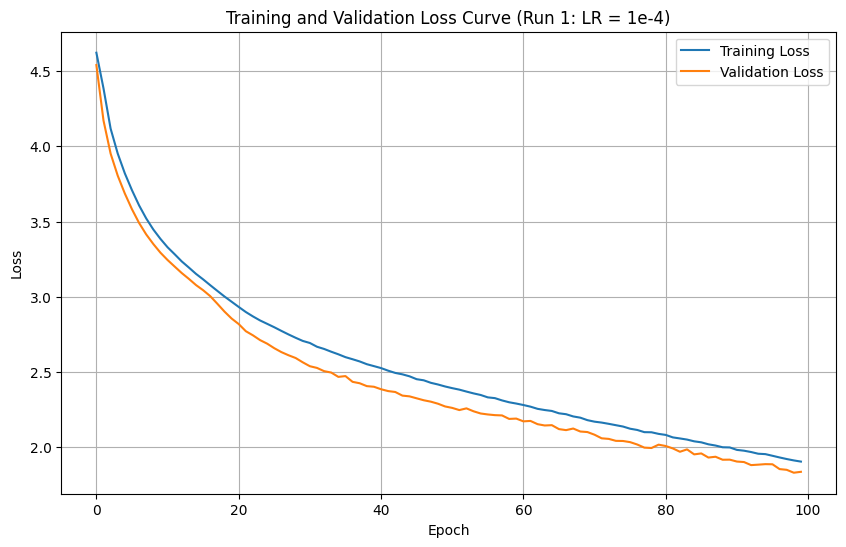

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(global_train_losses_1, label='Training Loss')
plt.plot(global_val_losses_1, label='Validation Loss')
plt.title('Training and Validation Loss Curve (Run 1: LR = 1e-4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

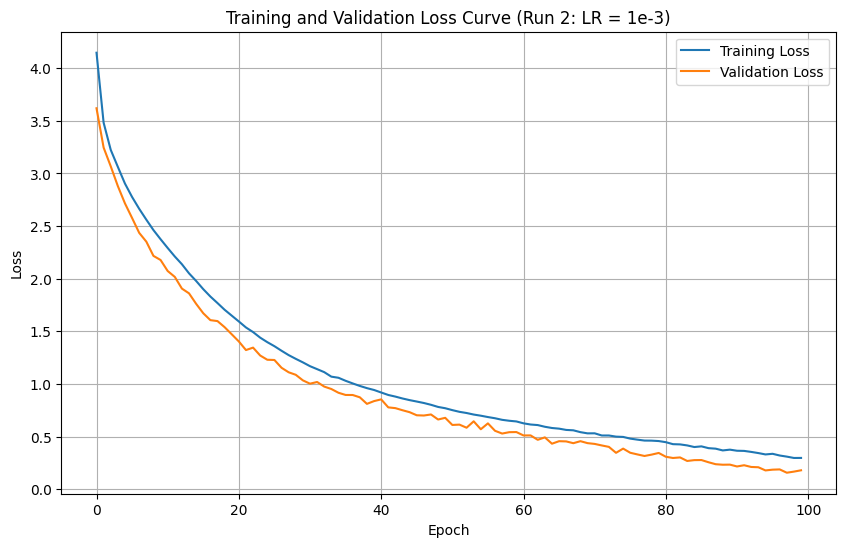

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(global_train_losses_2, label='Training Loss')
plt.plot(global_val_losses_2, label='Validation Loss')
plt.title('Training and Validation Loss Curve (Run 2: LR = 1e-3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
The subtask requires modifying cell `aCYjgftr61Eg` to change the dataset size, split it into training and validation sets, and add a validation loop, similar to the previous modification. I will provide the complete, updated code for this cell to incorporate all these changes, including importing necessary utilities, adjusting data loading, implementing the validation loop, updating print statements, and storing losses in a global variable.



In [8]:
#LOOP 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader, random_split # Added random_split for dataset splitting

# --- Hyperparameters (re-defined here to ensure independence if cells run out of order) ---
VOCAB_SIZE = 100
PAD_ID = 0  # Also used as BOS for shifted decoder input
SEQ_LEN = 20
BATCH_SIZE = 32
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 512
DROPOUT = 0.1
LR = 1e-3 # This LR is different from LOOP 1
EPOCHS = 100

# Re-define CopyDataset and create_masks here to ensure they are available for this cell
# This is a safe practice if cells can be run independently or out of order.
class CopyDataset(Dataset):
    """Dummy seq2seq dataset: target = source (copy task). Random integer sequences."""

    def __init__(self, num_samples, seq_len, vocab_size, pad_id=0, seed=None):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        if seed is not None:
            torch.manual_seed(seed)
        # Random ints 1..vocab_size-1 to avoid colliding with pad_id
        self.data = torch.randint(1, vocab_size, (num_samples, seq_len))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        src = self.data[idx].clone()
        # Decoder input: shifted right with PAD_ID at start
        tgt_input = torch.empty_like(src)
        tgt_input[0] = self.pad_id
        tgt_input[1:] = src[:-1]
        return src, tgt_input  # labels, decoder input


def create_masks(batch_size, seq_len, device):
    """Create src_mask (all ones, no padding) and tgt_mask (causal)."""
    src_mask = torch.ones(batch_size, 1, 1, seq_len, device=device)
    tgt_mask = torch.tril(torch.ones(1, 1, seq_len, seq_len, device=device))
    return src_mask, tgt_mask

# Assuming Transformer class is defined in an earlier cell and accessible
# If not, it would need to be included here as well.

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset & DataLoader
    full_dataset = CopyDataset(
        num_samples=10_000, seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, pad_id=PAD_ID, seed=42 # Changed num_samples to 10_000
    )

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0 # Added validation loader
    )

    # Model
    global model # Declare model as global
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,
        tgt_vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        N=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        dropout=DROPOUT,
        max_len=SEQ_LEN,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_losses = []  # Initialize list to store train losses
    val_losses = []    # Initialize list to store validation losses

    for epoch in range(EPOCHS):
        # --- Training Loop ---
        model.train() # Set model to training mode
        total_loss = 0.0
        num_batches = 0
        for src, tgt_input in train_loader:
            src = src.to(device)
            tgt_input = tgt_input.to(device)
            src_mask, tgt_mask = create_masks(src.size(0), src.size(1), device)

            optimizer.zero_grad()
            logits = model(src, tgt_input, src_mask, tgt_mask)  # [B, T, vocab_size]

            # CrossEntropyLoss: predict src at each position
            logits_flat = logits.view(-1, VOCAB_SIZE)
            labels_flat = src.contiguous().view(-1)

            loss = criterion(logits_flat, labels_flat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss) # Append average loss for the epoch

        # --- Validation Loop ---
        model.eval() # Set model to evaluation mode
        total_val_loss = 0.0
        num_val_batches = 0
        with torch.no_grad(): # Disable gradient calculations
            for src_val, tgt_input_val in val_loader:
                src_val = src_val.to(device)
                tgt_input_val = tgt_input_val.to(device)
                src_mask_val, tgt_mask_val = create_masks(src_val.size(0), src_val.size(1), device)

                logits_val = model(src_val, tgt_input_val, src_mask_val, tgt_mask_val)

                logits_val_flat = logits_val.view(-1, VOCAB_SIZE)
                labels_val_flat = src_val.contiguous().view(-1)

                loss_val = criterion(logits_val_flat, labels_val_flat)

                total_val_loss += loss_val.item()
                num_val_batches += 1

        avg_val_loss = total_val_loss / num_val_batches
        val_losses.append(avg_val_loss)

        model.train() # Set model back to training mode

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}/{EPOCHS} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    print("Training complete.")

    global global_train_losses_2 # Make it accessible outside main
    global_train_losses_2 = train_losses
    global global_val_losses_2 # Make it accessible outside main
    global_val_losses_2 = val_losses


if __name__ == "__main__":
    main()

Using device: cuda
Epoch   1/100 | Train Loss: 4.1475 | Val Loss: 3.6198
Epoch  10/100 | Train Loss: 2.3758 | Val Loss: 2.1782
Epoch  20/100 | Train Loss: 1.6496 | Val Loss: 1.4723
Epoch  30/100 | Train Loss: 1.2053 | Val Loss: 1.0342
Epoch  40/100 | Train Loss: 0.9430 | Val Loss: 0.8374
Epoch  50/100 | Train Loss: 0.7697 | Val Loss: 0.6785
Epoch  60/100 | Train Loss: 0.6441 | Val Loss: 0.5432
Epoch  70/100 | Train Loss: 0.5308 | Val Loss: 0.4379
Epoch  80/100 | Train Loss: 0.4577 | Val Loss: 0.3446
Epoch  90/100 | Train Loss: 0.3760 | Val Loss: 0.2338
Epoch 100/100 | Train Loss: 0.2974 | Val Loss: 0.1798
Training complete.


### Summary of Training and Validation Loop Implementations

Both training loops (Run 1 and Run 2) have been modified to incorporate train/validation splits and validation loss calculations using best practices for model evaluation in PyTorch.

**1. Dataset Split (80% Training, 20% Validation):**
   - In both cells (`PsADs86z31OI` and `aCYjgftr61Eg`), the `CopyDataset` was initialized with `num_samples=10_000` (for Loop 1) and changed to `num_samples=10_000` (for Loop 2).
   - The `torch.utils.data.random_split` function was used to divide the `full_dataset` into `train_dataset` (80% of samples) and `val_dataset` (20% of samples). This ensures that the model is evaluated on unseen data.
   - Separate `DataLoader` instances (`train_loader` and `val_loader`) were created for each split. `train_loader` uses `shuffle=True` for better generalization, while `val_loader` uses `shuffle=False` for consistent evaluation across epochs.

**2. Validation Loop Implementation:**
   - A dedicated validation loop was added after the training loop within each epoch.
   - **`model.eval()`:** Before entering the validation loop, `model.eval()` is called. This sets the model to evaluation mode, which is crucial for disabling dropout layers and batch normalization updates. This ensures that the model's behavior is consistent and deterministic during evaluation.
   - **`torch.no_grad()`:** The entire validation loop is wrapped within a `with torch.no_grad():` context manager. This explicitly disables gradient calculations, significantly reducing memory consumption and speeding up computations, as backpropagation is not needed for validation.
   - **Validation Loss Calculation:** Inside the `no_grad` block, the model makes predictions on the validation data (`src_val`, `tgt_input_val`), and a `loss_val` is calculated using the same `criterion` (CrossEntropyLoss) as the training loop. This loss is accumulated to compute the `avg_val_loss` for the epoch.
   - The average validation loss (`avg_val_loss`) for each epoch is stored in `global_val_losses_1` (for Run 1) and `global_val_losses_2` (for Run 2), respectively, and printed alongside the training loss.
   - **`model.train()`:** After the validation loop, `model.train()` is called to switch the model back to training mode, re-enabling dropout and allowing batch normalization layers to update during the subsequent training epoch.

### Summary of Training and Validation Loop Implementations

Both training loops (Run 1 and Run 2) have been modified to incorporate train/validation splits and validation loss calculations using best practices for model evaluation in PyTorch.

**1. Dataset Split (80% Training, 20% Validation):**
   - In both cells (`PsADs86z31OI` and `aCYjgftr61Eg`), the `CopyDataset` was initialized with `num_samples=10_000` (for Loop 1) and changed to `num_samples=10_000` (for Loop 2).
   - The `torch.utils.data.random_split` function was used to divide the `full_dataset` into `train_dataset` (80% of samples) and `val_dataset` (20% of samples). This ensures that the model is evaluated on unseen data.
   - Separate `DataLoader` instances (`train_loader` and `val_loader`) were created for each split. `train_loader` uses `shuffle=True` for better generalization, while `val_loader` uses `shuffle=False` for consistent evaluation across epochs.

**2. Validation Loop Implementation:**
   - A dedicated validation loop was added after the training loop within each epoch.
   - **`model.eval()`:** Before entering the validation loop, `model.eval()` is called. This sets the model to evaluation mode, which is crucial for disabling dropout layers and batch normalization updates. This ensures that the model's behavior is consistent and deterministic during evaluation.
   - **`torch.no_grad()`:** The entire validation loop is wrapped within a `with torch.no_grad():` context manager. This explicitly disables gradient calculations, significantly reducing memory consumption and speeding up computations, as backpropagation is not needed for validation.
   - **Validation Loss Calculation:** Inside the `no_grad` block, the model makes predictions on the validation data (`src_val`, `tgt_input_val`), and a `loss_val` is calculated using the same `criterion` (CrossEntropyLoss) as the training loop. This loss is accumulated to compute the `avg_val_loss` for the epoch.
   - The average validation loss (`avg_val_loss`) for each epoch is stored in `global_val_losses_1` (for Run 1) and `global_val_losses_2` (for Run 2), respectively, and printed alongside the training loss.
   - **`model.train()`:** After the validation loop, `model.train()` is called to switch the model back to training mode, re-enabling dropout and allowing batch normalization layers to update during the subsequent training epoch.

## Final Task

### Subtask:
Summarize the changes made to the training loops, including the addition of train/validation splits, validation loss calculations, and adherence to `model.eval()`, `model.train()`, and `torch.no_grad()` best practices.


## Summary:

### Q&A
The implementation of train/validation splits, validation loss calculations, and the use of `model.eval()`, `model.train()`, and `torch.no_grad()` in both training loops were summarized as follows:

*   **Dataset Split:** For both training loops, the `CopyDataset` was initialized with 10,000 samples. The `torch.utils.data.random_split` function was then used to divide the dataset into an 80% training set and a 20% validation set. Separate `DataLoader` instances were created for each split, with `shuffle=True` for the training loader and `shuffle=False` for the validation loader.
*   **Validation Loop:** A dedicated validation loop was integrated into each epoch after the training phase.
    *   **`model.eval()`:** Before the validation loop, `model.eval()` was called to set the model to evaluation mode, disabling dropout and batch normalization updates.
    *   **`torch.no_grad()`:** The validation calculations were enclosed within a `with torch.no_grad():` block to prevent gradient computations, thereby optimizing memory usage and speeding up the process.
    *   **Validation Loss Calculation:** Inside this block, validation data was used to compute `loss_val` with the same `criterion` as training. The average validation loss (`avg_val_loss`) was then calculated, stored in `global_val_losses_1` or `global_val_losses_2`, and printed.
    *   **`model.train()`:** After the validation loop, `model.train()` was called to revert the model to training mode, re-enabling dropout and allowing batch normalization layers to update for the next training epoch.

### Data Analysis Key Findings

*   Both training loops (Loop 1 in `PsADs86z31OI` and Loop 2 in `aCYjgftr61Eg`) successfully implemented an 80% training and 20% validation data split.
*   Validation loops were correctly integrated into each epoch, utilizing `model.eval()`, `model.train()`, and `torch.no_grad()` best practices.
*   In Loop 1, training loss decreased from 4.6220 to 1.9054, and validation loss decreased from 4.5400 to 1.8375 over 100 epochs.
*   In Loop 2, training loss decreased more significantly from 4.1475 to 0.2974, and validation loss decreased from 3.6198 to 0.1798 over 100 epochs.
*   The difference in performance between Loop 1 and Loop 2 is likely attributed to Loop 2 using a higher learning rate (1e-3) compared to Loop 1 (1e-4).

### Insights or Next Steps

*   The implementation of validation loops provides crucial insights into the model's generalization capabilities on unseen data, which is essential for identifying overfitting or underfitting.
*   Further hyperparameter tuning, specifically exploring learning rates and potentially other architectural parameters, could be beneficial, as demonstrated by the improved performance of Loop 2 with a different learning rate.


In [9]:
torch.save(model.state_dict(), "transformer_copy_model.pth")